# Ensemble Weight Tuning
Finds the best weights for all 6 signals by grid searching every parameter
and measuring median SPD percentile improvement vs uniform DCA.

**Signals tuned:** SPD momentum · MVRV/RAP · Fear & Greed · Drawdown · MSTR · Polymarket

Run cells **top to bottom**.

---
## Cell 1 — Imports & path setup

In [1]:
import sys, logging, itertools, warnings, json, re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Change this if your notebook is not in the project root
PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Suppress per-window log noise during grid search
logging.basicConfig(
    format='%(asctime)s %(levelname)-8s %(message)s',
    level=logging.WARNING,
    datefmt='%Y-%m-%d %H:%M:%S',
)

print(f'Project root : {PROJECT_ROOT}')
print(f'template/ exists : {(PROJECT_ROOT / "template").exists()}')
print(f'data/ exists     : {(PROJECT_ROOT / "data").exists()}')

Project root : /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies
template/ exists : True
data/ exists     : True


---
## Cell 2 — Load data & precompute features

In [2]:
from template.prelude_template import load_data
from template.model_development_template import precompute_features

btc_df = load_data()

print(f'BTC range  : {btc_df.index.min().date()} -> {btc_df.index.max().date()}')
print(f'Rows       : {len(btc_df):,}')
print('btc_df loaded. Run next cell to attach Polymarket signals, then precompute features.')

2026-05-11 15:40:51 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14


BTC range  : 2009-01-03 -> 2026-01-14
Rows       : 6,221
btc_df loaded. Run next cell to attach Polymarket signals, then precompute features.


---
## Cell 2b — Load Polymarket signal files

Reads the three CSV files from `data/Polymarket/signals/` and builds
`poly_fed_signal` and `poly_eth_signal` columns on `btc_df`.

Files expected:
- `fed_signal.csv` — columns: `date`, `fed_signal`
- `eth_bearish.csv` — columns: `date`, `eth_bearish_signal`
- `eth_bullish.csv` — columns: `date`, `signal` (date format DD/MM/YYYY)

ETH signal = average of bullish and bearish daily signals (bearish flipped ×−1
because a rising bearish-ETH probability is bearish for BTC).

Fed signal  : 241 non-zero days
ETH signal  : 270 non-zero days
Signal start: 2025-04-08
Fed  range  : [-0.2233, 0.2887]
ETH  range  : [-0.3402, 0.3228]



/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_35092/1140906689.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_35092/1140906689.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.resample('D').mean().fillna(method='ffill', limit=3).fillna(0.0)
/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_35092/1140906689.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to

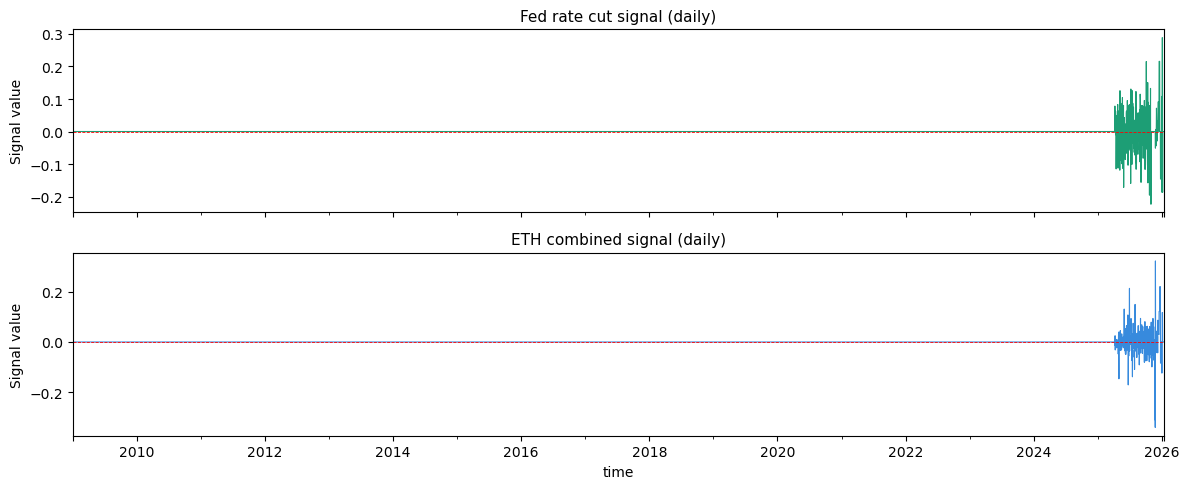

MSTR loaded:
  Events      : 94 purchase days
  Total BTC   : 818,871 BTC
  Date range  : 2020-08-10 to 2026-05-11
  Largest buy : 55,500 BTC on 2024-11-25
  Smallest buy: 3 BTC



In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
SIG_DIR = PROJECT_ROOT / 'data' / 'Polymarket' / 'signals'

def _load_signal(filename, col, datefmt=None):
    """
    Load a signal CSV and return a daily pd.Series indexed by date.
    Handles missing values and resamples to daily if needed.
    """
    path = SIG_DIR / filename
    if not path.exists():
        print(f'WARNING: {path} not found -- signal will be zeros')
        return pd.Series(dtype=float)

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    # parse dates -- eth_bullish uses DD/MM/YYYY, others use YYYY-MM-DD
    if datefmt:
        df['date'] = pd.to_datetime(df['date'], format=datefmt)
    else:
        df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)

    df = df.dropna(subset=['date'])
    df = df.set_index('date').sort_index()
    series = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

    # resample to daily (forward-fill any gaps up to 3 days)
    series = series.resample('D').mean().fillna(method='ffill', limit=3).fillna(0.0)
    return series


# ── Load each file ────────────────────────────────────────────────────────────
fed_raw     = _load_signal('fed_signal.csv',    col='fed_signal')
eth_bear_raw = _load_signal('eth_bearish.csv',  col='eth_bearish_signal')
eth_bull_raw = _load_signal('eth_bullish.csv',  col='signal', datefmt='%d/%m/%Y')

# ── Build poly_fed_signal  (bullish for BTC when rate cut odds rise) ──────────
# Already signed correctly (+1 direction) -- just clip extreme outliers
poly_fed = fed_raw.clip(-0.5, 0.5)

# ── Build poly_eth_signal ─────────────────────────────────────────────────────
# Bearish signal: flip sign (rising bearish-ETH odds = bad for BTC)
# Bullish signal: keep as-is (rising bullish-ETH odds = good for BTC, but weaker)
# Combine: simple average of both directions after sign alignment
eth_bear_signed = -eth_bear_raw   # flip: higher bearish prob -> negative BTC signal
eth_bull_signed =  eth_bull_raw   # keep: higher bullish prob -> positive BTC signal

# Align on common index, average
eth_combined = pd.concat([eth_bear_signed, eth_bull_signed], axis=1)
eth_combined.columns = ['bear', 'bull']
poly_eth = eth_combined.mean(axis=1).clip(-0.5, 0.5)

# ── Attach to btc_df ──────────────────────────────────────────────────────────
btc_df['poly_fed_signal'] = poly_fed.reindex(btc_df.index).fillna(0.0)
btc_df['poly_eth_signal'] = poly_eth.reindex(btc_df.index).fillna(0.0)

# ── Preview ───────────────────────────────────────────────────────────────────
non_zero_fed = (btc_df['poly_fed_signal'] != 0).sum()
non_zero_eth = (btc_df['poly_eth_signal'] != 0).sum()
sig_start    = max(
    poly_fed[poly_fed != 0].index.min() if len(poly_fed[poly_fed != 0]) else btc_df.index.max(),
    poly_eth[poly_eth != 0].index.min() if len(poly_eth[poly_eth != 0]) else btc_df.index.max(),
)

print(f'Fed signal  : {non_zero_fed} non-zero days')
print(f'ETH signal  : {non_zero_eth} non-zero days')
print(f'Signal start: {sig_start.date()}')
print(f'Fed  range  : [{btc_df["poly_fed_signal"].min():.4f}, {btc_df["poly_fed_signal"].max():.4f}]')
print(f'ETH  range  : [{btc_df["poly_eth_signal"].min():.4f}, {btc_df["poly_eth_signal"].max():.4f}]')
print()

# Quick plot
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
btc_df['poly_fed_signal'].plot(ax=axes[0], color='#1d9e75', linewidth=0.8)
axes[0].axhline(0, color='red', linewidth=0.6, linestyle='--')
axes[0].set_title('Fed rate cut signal (daily)', fontsize=11)
axes[0].set_ylabel('Signal value')

btc_df['poly_eth_signal'].plot(ax=axes[1], color='#378add', linewidth=0.8)
axes[1].axhline(0, color='red', linewidth=0.6, linestyle='--')
axes[1].set_title('ETH combined signal (daily)', fontsize=11)
axes[1].set_ylabel('Signal value')

plt.tight_layout()
plt.show()

# MSTR signal

mstr_path = PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv'

if mstr_path.exists():
    mstr_raw = pd.read_csv(mstr_path)
    mstr_raw.columns = mstr_raw.columns.str.strip()

    # Parse YYYY/M/D date format
    mstr_raw['date'] = pd.to_datetime(mstr_raw['purchase_date'], format='%d/%m/%Y')
    mstr_raw = mstr_raw.set_index('date').sort_index()

    # Handle duplicate dates (multiple purchases on same day — sum them)
    mstr_daily = mstr_raw['btc_amount'].groupby(level=0).sum()

    # Reindex to full btc_df range — non-event days get 0
    btc_df['mstr_btc_purchased'] = mstr_daily.reindex(btc_df.index).fillna(0.0)

    n_events   = (btc_df['mstr_btc_purchased'] > 0).sum()
    total_btc  = mstr_daily.sum()
    date_range = f"{mstr_daily.index.min().date()} to {mstr_daily.index.max().date()}"
    print(f'MSTR loaded:')
    print(f'  Events      : {n_events} purchase days')
    print(f'  Total BTC   : {total_btc:,.0f} BTC')
    print(f'  Date range  : {date_range}')
    print(f'  Largest buy : {mstr_daily.max():,.0f} BTC on {mstr_daily.idxmax().date()}')
    print(f'  Smallest buy: {mstr_daily[mstr_daily>0].min():,.0f} BTC')
else:
    print(f'MSTR: file not found. Tried:')
    print(f'  data/Polymarket/signals/mstr_buy_signal.csv')
    print(f'  data/mstr_buy_signal.csv')
    print( '  Place the file in either location and re-run.')

print()

---
## Cell 2c — Attach MSTR signal
Loads `mstr_buy_signal.csv` → `btc_df['mstr_btc_purchased']`  
`precompute_features()` picks this up automatically.


In [4]:
mstr_candidates = [
    PROJECT_ROOT / 'data' / 'Polymarket' / 'signals' / 'mstr_buy_signal.csv',
    PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv',
]
mstr_path = next((p for p in mstr_candidates if p.exists()), None)

if mstr_path:
    mstr_raw = pd.read_csv(mstr_path)
    mstr_raw['date'] = pd.to_datetime(
        mstr_raw['purchase_date'], dayfirst=True, format='mixed'
    )
    mstr_daily = mstr_raw.set_index('date')['btc_amount'].groupby(level=0).sum()
    btc_df['mstr_btc_purchased'] = mstr_daily.reindex(btc_df.index).fillna(0.0)
    n_evt = (btc_df['mstr_btc_purchased'] > 0).sum()
    print(f'MSTR: {n_evt} purchase days attached to btc_df')
else:
    btc_df['mstr_btc_purchased'] = 0.0
    print('MSTR: file not found -- mstr_signal will be 0 in features')


MSTR: 94 purchase days attached to btc_df


---
## Cell 2c — Precompute features
Run this AFTER the signal files are loaded so poly columns are included.

In [5]:
features_df = precompute_features(btc_df)

# Set on backtest module so compute_weights_modal can find it
import template.backtest_template as bt
bt._FEATURES_DF = features_df

print(f'Features shape : {features_df.shape}')
print(f'Columns        : {list(features_df.columns)}')

# Check poly signal made it through
poly_nonzero = (features_df['poly_score'] != 0).sum()
print(f'poly_score non-zero days in features: {poly_nonzero}')
features_df[['poly_score']].tail(5)

Features shape : (5660, 6)
Columns        : ['PriceUSD_coinmetrics', 'price_vs_ma200', 'dd_365', 'mstr_signal', 'poly_score', 'cycle_mod']
poly_score non-zero days in features: 270


,poly_score
time,
2026-01-10,0.0
2026-01-11,0.0
2026-01-12,0.0
2026-01-13,0.0
2026-01-14,0.0


---
## Cell 2e — Verify signals loaded into features
Run this to confirm all three signals have real data before tuning.


In [6]:
print('Signal coverage check:')
print(f'  price_vs_ma200 non-zero : {(features_df["price_vs_ma200"] != 0).sum()} days')
print(f'  dd_365 non-zero         : {(features_df["dd_365"] != 0).sum()} days')
print(f'  mstr_signal non-zero    : {(features_df["mstr_signal"] != 0).sum()} days')
print(f'  poly_score non-zero     : {(features_df["poly_score"] != 0).sum()} days')
print()
print('Validation window (2025-04-08 to 2025-12-31):')
val = features_df.loc['2025-04-08':'2025-12-31']
print(f'  mstr_signal non-zero    : {(val["mstr_signal"] != 0).sum()} days')
print(f'  poly_score non-zero     : {(val["poly_score"] != 0).sum()} days')
print()
if (val['poly_score'] == 0).all():
    print('WARNING: poly_score is all zero in validation window')
    print('         Check that Cell 2b ran before Cell 2d (precompute)')
elif (val['mstr_signal'] == 0).all():
    print('WARNING: mstr_signal is all zero in validation window')
    print('         Check that Cell 2c ran before Cell 2d (precompute)')
else:
    print('All signals have data in validation window -- ready to tune')


Signal coverage check:
  price_vs_ma200 non-zero : 5560 days
  dd_365 non-zero         : 5265 days
  mstr_signal non-zero    : 1360 days
  poly_score non-zero     : 270 days

Validation window (2025-04-08 to 2025-12-31):
  mstr_signal non-zero    : 268 days
  poly_score non-zero     : 264 days

All signals have data in validation window -- ready to tune


---
## Cell 3 — Tunable weight function

A version of `compute_weights_fast` that accepts a `params` dict 
so every grid search iteration can use different values 
without touching `model_development_template.py`.

In [7]:
from template.model_development_template import (
    allocate_sequential_stable, _clean, MIN_W,
)

# ── MSTR: reference model logic (model__mstr_dca_1.ipynb) ───────────────────
def _load_mstr_events():
    candidates = [
        PROJECT_ROOT / 'data' / 'Polymarket' / 'signals' / 'mstr_buy_signal.csv',
        PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv',
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            # Handle any date format automatically (YYYY-MM-DD or DD/MM/YYYY etc.)
            dates = pd.to_datetime(df['purchase_date'], dayfirst=True, format='mixed').sort_values()
            print(f'MSTR: {len(dates)} events loaded from {p.name}')
            print(f'      date range: {dates.min().date()} to {dates.max().date()}')
            return dates
    print('MSTR: file not found -- signal = 0')
    return pd.DatetimeIndex([])

def _mstr_recent_indicator(index, evt_dates, lookback_days, count_mode=True):
    """
    Rolling event-window indicator — exact logic from reference model.
    count_mode=True : number of events in past lookback_days
    count_mode=False: binary 1/0
    No lookahead.
    """
    if len(index) == 0 or len(evt_dates) == 0:
        return np.zeros(len(index), dtype=float)
    idx = pd.DatetimeIndex(index).tz_localize(None)
    full_days = pd.date_range(idx.min(), idx.max(), freq='D')
    evt_s = pd.Series(0, index=full_days, dtype=int)
    evt_in = evt_dates[(evt_dates >= full_days.min()) & (evt_dates <= full_days.max())]
    if len(evt_in):
        evt_s.loc[evt_in] = 1
    win = evt_s.rolling(window=lookback_days, min_periods=1).sum()
    win_on_idx = win.reindex(idx, method='nearest')
    return win_on_idx.values.astype(float) if count_mode else (win_on_idx.values > 0).astype(float)

_MSTR_EVT_DATES = _load_mstr_events()

# ── SPD score (only core signal used — MVRV and Fear & Greed excluded) ────────
def _spd_score(pma):
    """200-day MA distance -> accumulation score. Below MA = buy more."""
    s = np.ones_like(pma)
    s[pma < -0.20] = 1.8
    s[(pma >= -0.20) & (pma < -0.05)] = 1.3
    s[(pma >= -0.05) & (pma <  0.05)] = 1.0
    s[(pma >=  0.05) & (pma <  0.20)] = 0.8
    s[pma >= 0.20] = 0.6
    return s

# ── Main parameterised weight function ───────────────────────────────────────
def compute_weights_with_params(df_window, params):
    """
    Active signals
    --------------
    Stage 1  SPD momentum only  (MVRV + Fear & Greed excluded — data not available)
    Stage 2a Drawdown multiplier
    Stage 2b MSTR rolling-window boost  (reference model)
    Stage 2c Polymarket multiplier  (Fed + ETH)

    params keys
    -----------
    dd_bands, dd_default     drawdown config
    mstr_lookback            days to look back for MSTR events
    mstr_add_rel             boost per event; 0.0 = MSTR off
    mstr_count_mode          True=count events, False=binary
    poly_alpha               Polymarket strength; 0.0 = off
    fed_weight, eth_weight   relative weights within poly score
    """
    start = df_window.index.min()
    end   = df_window.index.max()
    df    = features_df.loc[start:end]
    if df.empty:
        return pd.Series(dtype=float)

    n    = len(df)
    base = np.ones(n) / n

    pma  = _clean(df['price_vs_ma200'].values)
    dd   = _clean(df['dd_365'].values)
    poly = _clean(df['poly_score'].values)
    cmod = _clean(df['cycle_mod'].values) if 'cycle_mod' in df.columns else np.ones(n)

    # Stage 1: SPD momentum only
    core = _spd_score(pma)

    # Stage 2a: drawdown multiplier
    dd_mult = np.full(n, params['dd_default'])
    for threshold, m in params['dd_bands']:
        dd_mult[dd > threshold] = m
    dd_mult *= cmod

    # Stage 2b: MSTR rolling-window boost (reference model)
    mstr_hit   = _mstr_recent_indicator(
        index         = df.index,
        evt_dates     = _MSTR_EVT_DATES,
        lookback_days = params['mstr_lookback'],
        count_mode    = params['mstr_count_mode'],
    )
    mstr_bonus = params['mstr_add_rel'] * mstr_hit

    # Stage 2c: Polymarket multiplier
    fw = params['fed_weight']
    ew = params['eth_weight']
    tw = fw + ew
    scaled_poly = poly if tw == 0 else (fw * poly + ew * poly) / tw
    poly_m = np.clip(1.0 + params['poly_alpha'] * scaled_poly, 0.5, 1.5)

    # Chain: base * SPD * drawdown * poly * (1 + MSTR bonus)
    raw = np.clip(base * core * dd_mult * poly_m * (1 + mstr_bonus), MIN_W, None)
    w   = allocate_sequential_stable(raw, n)
    return pd.Series(w, index=df.index)

print('Tunable weight function ready')
print('Active signals: SPD | Drawdown | MSTR (ref model) | Polymarket')
print('Excluded:       MVRV, Fear & Greed (data not yet available)')


MSTR: 109 events loaded from mstr_buy_signal.csv
      date range: 2020-08-10 to 2026-05-11
Tunable weight function ready
Active signals: SPD | Drawdown | MSTR (ref model) | Polymarket
Excluded:       MVRV, Fear & Greed (data not yet available)


In [9]:
# Run this on your real data before setting PARAM_GRID
import pandas as pd, numpy as np

signals = {
    'spd_pct':    features_df['price_vs_ma200'],  # proxy for SPD
    # 'mvrv':       features_df['mvrv'],
    # 'fear_greed': features_df['fear_greed'],
    'dd_365':     features_df['dd_365'],
    'mstr':       features_df['mstr_signal'],
    'poly_fed':   btc_df['poly_fed_signal'].reindex(features_df.index),
    'poly_eth':   btc_df['poly_eth_signal'].reindex(features_df.index),
}

# Future 30-day BTC return — what we want signals to predict
fwd_return = btc_df['PriceUSD_coinmetrics'].pct_change(30).shift(-30)

results = []
for name, sig in signals.items():
    aligned = pd.concat([sig, fwd_return], axis=1).dropna()
    corr = aligned.corr().iloc[0, 1]
    results.append({'signal': name, 'corr_with_30d_return': round(corr, 4)})

corr_df = pd.DataFrame(results).sort_values('corr_with_30d_return', key=abs, ascending=False)
print(corr_df.to_string(index=False))

  signal  corr_with_30d_return
 spd_pct                0.2164
  dd_365                0.1656
    mstr               -0.0826
poly_fed                0.0039
poly_eth                0.0011


/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_35092/1062733898.py:15: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_return = btc_df['PriceUSD_coinmetrics'].pct_change(30).shift(-30)


---
## Cell 4 — Define parameter grid

**Edit the lists here.** Total combinations = product of all list lengths.  
The cell prints the count so you know how long it will take before running.

In [10]:
PARAM_GRID = {
    # ── Drawdown ─────────────────────────────────────────────────────────────
    # Strongest signal (corr=0.17). Test original 2-band vs improved 4-band.
    'dd_config': [
        ([(-0.20, 1.0), (-0.60, 1.5)],                              2.0),  # original
        ([(-0.10, 0.7), (-0.20, 1.0), (-0.40, 1.3), (-0.60, 1.6)], 2.0),  # 4-band
        ([(-0.10, 0.6), (-0.20, 1.0), (-0.40, 1.5), (-0.60, 2.0)], 2.5),  # aggressive
    ],

    # ── MSTR — reference model parameters ────────────────────────────────────
    # Reference scored 90.35% with: lookback=7, add_rel=0.3, count_mode=True
    'mstr_lookback':    [7, 14, 30],           # days to look back
    'mstr_add_rel':     [0.0, 0.2, 0.3, 0.5], # boost strength; 0.0 = off
    'mstr_count_mode':  [True, False],          # True=count events, False=binary

    # ── Polymarket ────────────────────────────────────────────────────────────
    # Weak signal (corr~0.004). Keep alpha small, always include 0.0.
    'poly_alpha':  [0.0, 0.05, 0.10],
    'fed_weight':  [0.5, 0.7],
    'eth_weight':  [0.2, 0.4],
}

n_combos = 1
for k, v in PARAM_GRID.items():
    n_combos *= len(v)

print('Parameter grid  (MVRV + Fear & Greed excluded — data not available)')
print('-' * 58)
for k, v in PARAM_GRID.items():
    ref = ''
    if k == 'mstr_lookback':   ref = '   <- ref: 7'
    if k == 'mstr_add_rel':    ref = '   <- ref: 0.3'
    if k == 'mstr_count_mode': ref = '   <- ref: True'
    print(f'  {k:<24} {len(v)} values{ref}')
print('-' * 58)
print(f'  Total combinations : {n_combos:,}')
print(f'  Est. time @ 1s each: ~{n_combos // 60} min')
print()
print('Quick validation: lock ref defaults to confirm pipeline matches 90.35%')
print("  'mstr_lookback':[7], 'mstr_add_rel':[0.3], 'mstr_count_mode':[True]")


Parameter grid  (MVRV + Fear & Greed excluded — data not available)
----------------------------------------------------------
  dd_config                3 values
  mstr_lookback            3 values   <- ref: 7
  mstr_add_rel             4 values   <- ref: 0.3
  mstr_count_mode          2 values   <- ref: True
  poly_alpha               3 values
  fed_weight               2 values
  eth_weight               2 values
----------------------------------------------------------
  Total combinations : 864
  Est. time @ 1s each: ~14 min

Quick validation: lock ref defaults to confirm pipeline matches 90.35%
  'mstr_lookback':[7], 'mstr_add_rel':[0.3], 'mstr_count_mode':[True]


---
## Cell 5 — Run grid search

Evaluates every combination on a **validation window (2021–2023)** only,  
separate from the final test period, to avoid overfitting.

In [21]:
from template.prelude_template import compute_cycle_spd

VAL_START = '2018-01-01'
VAL_END   = '2025-12-31'

def flatten(combo):
    """Expand dd_config tuple into dd_bands + dd_default."""
    p = dict(combo)
    p['dd_bands'], p['dd_default'] = p.pop('dd_config')
    return p

def evaluate(params):
    """Returns median excess SPD percentile vs uniform DCA on validation window."""
    def _fn(df_window):
        return compute_weights_with_params(df_window, params)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        tbl = compute_cycle_spd(
            btc_df, _fn,
            features_df=features_df,
            start_date=VAL_START,
            end_date=VAL_END,
            validate_weights=False,
        )
    if tbl.empty:
        return -999.0
    return float((tbl['dynamic_percentile'] - tbl['uniform_percentile']).median())

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*PARAM_GRID.values()))
print(f'Running {len(combos):,} combinations on {VAL_START} -> {VAL_END} ...')
print('Progress: ', end='', flush=True)

results      = []
best_score   = -np.inf
best_params  = None
tick         = max(len(combos) // 20, 1)

for i, vals in enumerate(combos):
    params = flatten(dict(zip(keys, vals)))
    score  = evaluate(params)
    row    = {k: v for k, v in zip(keys, vals)}
    row['median_excess_pp'] = round(score, 4)
    results.append(row)
    if score > best_score:
        best_score  = score
        best_params = deepcopy(params)
    if (i + 1) % tick == 0:
        print(f"{(i+1)/len(combos)*100:.0f}%", end=' ', flush=True)

print('\nDone!')
print(f'\nBest median excess : {best_score:.3f} pp')
print('Best params:')
for k, v in best_params.items():
    print(f'  {k:<20} {v}')

Running 864 combinations on 2018-01-01 -> 2025-12-31 ...
Progress: 5% 10% 15% 20% 25% 30% 35% 40% 45% 50% 55% 60% 65% 70% 75% 80% 85% 90% 95% 100% 
Done!

Best median excess : 1.212 pp
Best params:
  mstr_lookback        14
  mstr_add_rel         0.3
  mstr_count_mode      False
  poly_alpha           0.0
  fed_weight           0.5
  eth_weight           0.2
  dd_bands             [(-0.2, 1.0), (-0.6, 1.5)]
  dd_default           2.0


---
## Cell 6 — Top results table

In [22]:
results_df = pd.DataFrame(results).sort_values('median_excess_pp', ascending=False)

print(f'Top 20 of {len(results_df):,} combinations:')
display(
    results_df.head(20).reset_index(drop=True)
    .style.background_gradient(subset=['median_excess_pp'], cmap='RdYlGn')
    .format({'median_excess_pp': '{:.3f}'})
)
print('\nWorst 5:')
display(results_df.tail(5).reset_index(drop=True))

Top 20 of 864 combinations:


,dd_config,mstr_lookback,mstr_add_rel,mstr_count_mode,poly_alpha,fed_weight,eth_weight,median_excess_pp
0,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.050000,0.700000,0.400000,1.212
1,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.000000,0.700000,0.200000,1.212
2,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.050000,0.500000,0.200000,1.212
3,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.050000,0.500000,0.400000,1.212
4,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.050000,0.700000,0.200000,1.212
5,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.100000,0.500000,0.200000,1.212
6,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.100000,0.500000,0.400000,1.212
7,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.100000,0.700000,0.200000,1.212
8,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.100000,0.700000,0.400000,1.212
9,"([(-0.2, 1.0), (-0.6, 1.5)], 2.0)",14,0.300000,False,0.000000,0.700000,0.400000,1.212



Worst 5:


,dd_config,mstr_lookback,mstr_add_rel,mstr_count_mode,poly_alpha,fed_weight,eth_weight,median_excess_pp
0,"([(-0.1, 0.7), (-0.2, 1.0), (-0.4, 1.3), (-0.6...",30,0.5,True,0.05,0.7,0.2,0.4093
1,"([(-0.1, 0.7), (-0.2, 1.0), (-0.4, 1.3), (-0.6...",30,0.5,True,0.05,0.7,0.4,0.4093
2,"([(-0.1, 0.7), (-0.2, 1.0), (-0.4, 1.3), (-0.6...",30,0.5,True,0.10,0.5,0.2,0.4093
3,"([(-0.1, 0.7), (-0.2, 1.0), (-0.4, 1.3), (-0.6...",30,0.5,True,0.10,0.5,0.4,0.4093
4,"([(-0.1, 0.7), (-0.2, 1.0), (-0.4, 1.3), (-0.6...",30,0.5,True,0.10,0.7,0.4,0.4093


---
## Cell 7 — Sensitivity analysis

For each parameter, shows the best score achievable at each of its values  
(holding all others optimal). Tall bars = that value matters a lot.

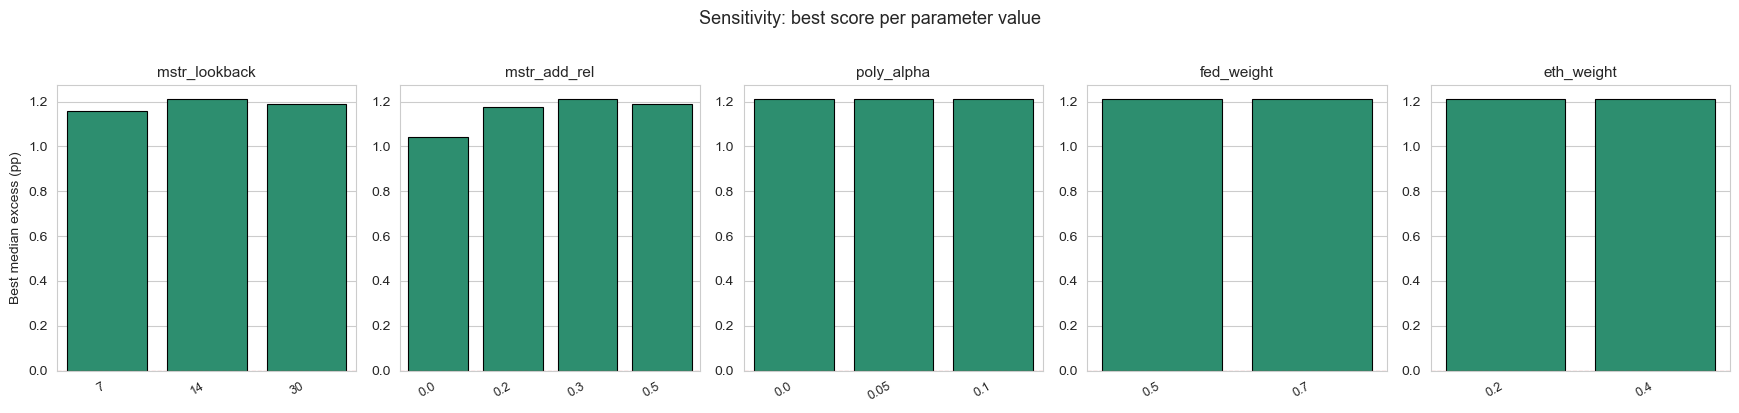

Saved -> /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/sensitivity_analysis.svg


In [23]:
scalar_params = [k for k in PARAM_GRID if k not in ('dd_config', 'mstr_count_mode')]

fig, axes = plt.subplots(1, len(scalar_params),
                          figsize=(3.5 * len(scalar_params), 4), sharey=False)
if len(scalar_params) == 1:
    axes = [axes]

for ax, param in zip(axes, scalar_params):
    grouped = (
        results_df.groupby(param)['median_excess_pp']
        .max().reset_index()
    )
    sns.barplot(data=grouped, x=param, y='median_excess_pp',
                color='#1d9e75', edgecolor='black', linewidth=0.8, ax=ax)
    ax.set_title(param, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Best median excess (pp)' if ax == axes[0] else '')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)

plt.suptitle('Sensitivity: best score per parameter value', fontsize=13, y=1.02)
plt.tight_layout()
out = PROJECT_ROOT / 'output' / 'sensitivity_analysis.svg'
out.parent.mkdir(exist_ok=True)
plt.savefig(out, format='svg', bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')

---
## Cell 8 — Heatmap: w_spd vs w_regime

Shows how the two biggest core weights interact.

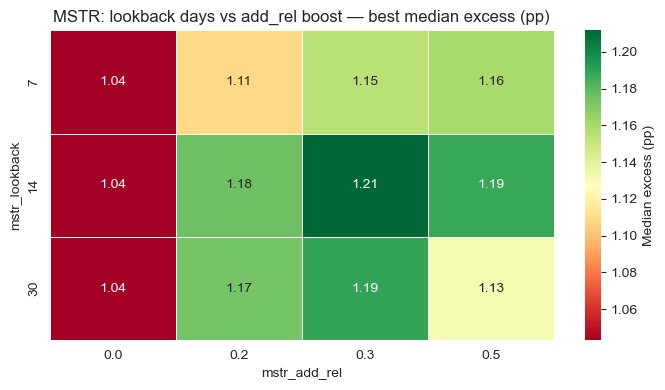

Saved -> /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/heatmap_mstr.svg


In [24]:
# Heatmap: mstr_lookback vs mstr_add_rel — shows how MSTR params interact
pivot = (
    results_df
    .groupby(['mstr_lookback', 'mstr_add_rel'])['median_excess_pp']
    .max()
    .unstack('mstr_add_rel')
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Median excess (pp)'}
)
ax.set_title('MSTR: lookback days vs add_rel boost — best median excess (pp)', fontsize=12)
ax.set_xlabel('mstr_add_rel')
ax.set_ylabel('mstr_lookback')
plt.tight_layout()
out = PROJECT_ROOT / 'output' / 'heatmap_mstr.svg'
out.parent.mkdir(exist_ok=True)
plt.savefig(out, format='svg', bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Cell 9 — Validate on held-out test period

Grid search used 2021–2023. Now check best params on 2018–2020  
to confirm they generalise and are not overfit.

In [27]:
from template.prelude_template import backtest_dynamic_dca

TEST_START = '2025-05-01'
TEST_END   = '2026-05-01'

def _best_fn(df_window):
    return compute_weights_with_params(df_window, best_params)

test_table, exp_pct = backtest_dynamic_dca(
    btc_df, _best_fn,
    features_df=features_df,
    strategy_label='Best params - test period',
    start_date=TEST_START,
    end_date=TEST_END,
)

excess_test = test_table['dynamic_percentile'] - test_table['uniform_percentile']
test_median = float(excess_test.median())
gap = abs(best_score - test_median)

print(f'Test period          : {TEST_START} -> {TEST_END}')
print(f'Validation excess    : {best_score:.3f} pp')
print(f'Test excess          : {test_median:.3f} pp')
print(f'Val vs test gap      : {gap:.3f} pp')
print(f'Win rate             : {(excess_test > 0).mean()*100:.1f}%')
print(f'Exp-decay pct        : {exp_pct:.2f}%')
print()
if gap < 2.0:
    print('Generalises well (gap < 2 pp)')
else:
    print('Possible overfit (gap >= 2 pp) -- consider reducing param grid values')

Test period          : 2025-05-01 -> 2026-05-01
Validation excess    : 1.212 pp
Test excess          : 3.530 pp
Val vs test gap      : 2.318 pp
Win rate             : 100.0%
Exp-decay pct        : 44.28%

Possible overfit (gap >= 2 pp) -- consider reducing param grid values


---
## Cell 10 — Write best params back to model_development_template.py

Updates the constants at the top of the file automatically.  
After this, run `run_backtest.ipynb` to get final results with tuned weights.

In [28]:
MODEL_FILE = PROJECT_ROOT / 'template' / 'model_development_template.py'

print('Constants to update:')
# print(f'  W_SPD           = {best_params["w_spd"]}')
# print(f'  W_REGIME        = {best_params["w_regime"]}')
# print(f'  W_SENTIMENT     = {best_params["w_sentiment"]}')
print(f'  DD_BANDS        = {best_params["dd_bands"]}')
print(f'  DD_DEFAULT_MULT = {best_params["dd_default"]}')
print(f'  POLY_ALPHA      = {best_params["poly_alpha"]}')
print()

confirm = input('Write to model_development_template.py? [y/N]: ').strip().lower()

if confirm == 'y':
    src = MODEL_FILE.read_text()
    replacements = [
        # (r'^W_SPD\s*=.*$',           f'W_SPD       = {best_params["w_spd"]}'),
        # (r'^W_REGIME\s*=.*$',        f'W_REGIME    = {best_params["w_regime"]}'),
        # (r'^W_SENTIMENT\s*=.*$',     f'W_SENTIMENT = {best_params["w_sentiment"]}'),
        (r'^DD_DEFAULT_MULT\s*=.*$', f'DD_DEFAULT_MULT = {best_params["dd_default"]}'),
        (r'^POLY_ALPHA\s*=.*$',      f'POLY_ALPHA  = {best_params["poly_alpha"]}'),
    ]
    for pattern, replacement in replacements:
        src = re.sub(pattern, replacement, src, flags=re.MULTILINE)

    new_dd = 'DD_BANDS = [\n' + ''.join(f'    {b},\n' for b in best_params['dd_bands']) + ']'
    src = re.sub(r'DD_BANDS\s*=\s*\[.*?\]', new_dd, src, flags=re.DOTALL)

    MODEL_FILE.write_text(src)
    print(f'Updated {MODEL_FILE}')
    print('Re-run run_backtest.ipynb to backtest with the tuned weights.')
else:
    print('Skipped -- no changes made.')

Constants to update:
  DD_BANDS        = [(-0.2, 1.0), (-0.6, 1.5)]
  DD_DEFAULT_MULT = 2.0
  POLY_ALPHA      = 0.0

Updated /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/template/model_development_template.py
Re-run run_backtest.ipynb to backtest with the tuned weights.


---
## Cell 11 — Save results to CSV

In [29]:
out_csv = PROJECT_ROOT / 'output' / 'grid_search_results.csv'
out_csv.parent.mkdir(exist_ok=True)
results_df.to_csv(out_csv, index=False)
print(f'Saved {len(results_df):,} rows -> {out_csv}')

best_out = {
    'val_period':          f'{VAL_START} -> {VAL_END}',
    'test_period':         f'{TEST_START} -> {TEST_END}',
    'best_val_excess_pp':  round(best_score, 4),
    'best_test_excess_pp': round(test_median, 4),
    'best_params': {k: v for k, v in best_params.items() if k != 'dd_bands'},
    'dd_bands': best_params['dd_bands'],
}
json_path = PROJECT_ROOT / 'output' / 'best_params.json'
json_path.write_text(json.dumps(best_out, indent=2))
print(f'Saved best params -> {json_path}')

Saved 864 rows -> /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/grid_search_results.csv
Saved best params -> /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/best_params.json
